In [1]:
# %%
from __future__ import print_function

import numpy as np 
import matplotlib.pyplot as plt
import openpathsampling as paths

# we use the %run magic because this isn't in a package
%run ../Toy_potentials.py
%run ../../Resources/toy_plot_helpers.py

/Users/rbreeba/miniconda3/envs/py39_AIMMD/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import openpathsampling.engines.toy as toys
pes = potential_WQ()
n_harmonics = pes.n_harmonics


123
pot dimensions without oscillators: 2
harmonic oscillators omegas:
array([0.        , 0.        , 1.        , 1.5       , 7.57175348,
       4.28911468, 3.81481163, 6.41051815, 7.75575176, 5.38485168,
       9.84611359, 7.47863791, 5.84745521, 5.13694015, 4.74542413,
       7.83239766, 5.50857796, 2.47742317, 5.18435404, 7.90396325,
       3.45993384, 3.40361405])


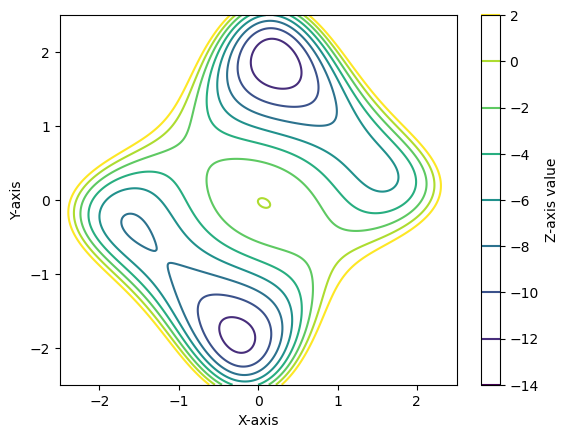

In [3]:
x = np.linspace(pes.extent[0],pes.extent[1],300)
y = np.linspace(pes.extent[2],pes.extent[3],300)
x_2d, y_2d, U = pes.plot_2d_pes(x,y)
# Step 2: Create the colormap
colormap = 'plasma'  # You can choose a different colormap from Matplotlib's colormaps

# Step 3: Generate the 2D image

plt.figure()
plt.contour(x_2d,y_2d,U, levels = pes.levels)
plt.colorbar(label='Z-axis value')  # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [4]:

integ = toys.LangevinBAOABIntegrator(dt=0.05, temperature=1, gamma=2.5)
options={
    'integ' : integ,
    'n_frames_max' : 5000,
    'n_steps_per_frame' : 1
}
toy_eng = toys.Engine(
    options=options,
    topology=pes.topology
)
toy_eng.initialized = True

template = pes.template(toy_eng)
toy_eng.current_snapshot = template
paths.PathMover.engine = toy_eng

# Collective variables to define the states
opA = paths.CoordinateFunctionCV(name="opA", f=pes.stable_interface_function, center=pes.state_A)
opB = paths.CoordinateFunctionCV(name="opB", f=pes.stable_interface_function, center=pes.state_B)

# State volumes in CV space
stateA = paths.CVDefinedVolume(opA, 0.0, pes.state_boundary).named('StateA')
stateB = paths.CVDefinedVolume(opB, 0.0, pes.state_boundary).named('StateB')
#

In [5]:
# Fake an initial trajectory
init_AB = paths.Trajectory(pes.simple_initial_path(1000,toy_eng))


In [6]:
# %%
network = paths.TPSNetwork(stateA, stateB)
move_scheme = paths.OneWayShootingMoveScheme(network, engine=toy_eng)

# %%
initial_conditions = move_scheme.initial_conditions_from_trajectories(init_AB)

# %%
initial_conditions.sanity_check()


No missing ensembles.
No extra ensembles.


In [7]:
# %%
storage = paths.Storage("simple_store.nc", "w", template=template)
storage.save(toy_eng)
storage.save(move_scheme)
storage.save(network)


(store.networks[TransitionNetwork] : 1 object(s),
 13,
 52917991827739981009734207513865226220)

In [8]:
for s in initial_conditions.samples:
    print(s)

Sample(RepID: 0, Ens: <openpathsampling.ensemble.SequentialEnsemble object at 0x163184d90>, Trajectory[903])


In [10]:
sampler = paths.PathSampling(storage, move_scheme, initial_conditions)

n_run = 10
sampler.run(n_run)

Working on Monte Carlo cycle number 10
Running for 1 minute 35 seconds - 10.63 seconds per step
Estimated time remaining: 10 seconds
DONE! Completed 10 Monte Carlo cycles.


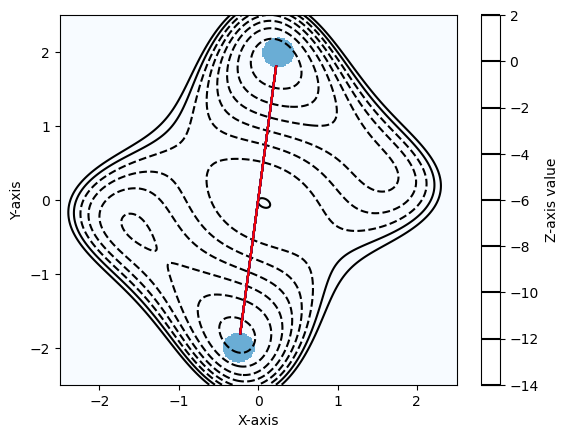

In [11]:
trajectories = [step.active[0].trajectory for step in storage.steps[:]]
plt.figure()
plt.contour(x_2d,y_2d,U, pes.levels,colors='k')
plt.colorbar(label='Z-axis value') 
repcolordict = {0 : 'k-', 1 : 'r-', 2 : 'g-', 3 : 'b-', 4 : 'r-'}
for i, traj in enumerate(trajectories):
    plt.plot(traj.xyz[:,0,0], traj.xyz[:,0,1], repcolordict[i % 5])

states_plot = np.vectorize(CallableVolume(stateA))(x_2d, -y_2d)
states_plot += np.vectorize(CallableVolume(stateB))(x_2d, -y_2d)
plt.imshow(states_plot, extent=pes.extent, cmap="Blues",
            interpolation='nearest', vmin=0.0, vmax=2.0,
            aspect='auto')
 # Add a colorbar to show the intensity scale
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

In [ ]:
storage.close()